11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 102s 214ms/step - loss: 0.0384 - val_loss: 0.0157
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 95s 203ms/step - loss: 0.0152 - val_loss: 0.0146
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 95s 202ms/step - loss: 0.0145 - val_loss: 0.0141
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 94s 201ms/step - loss: 0.0140 - val_loss: 0.0137
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 141s 200ms/step - loss: 0.0137 - val_loss: 0.0134
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step


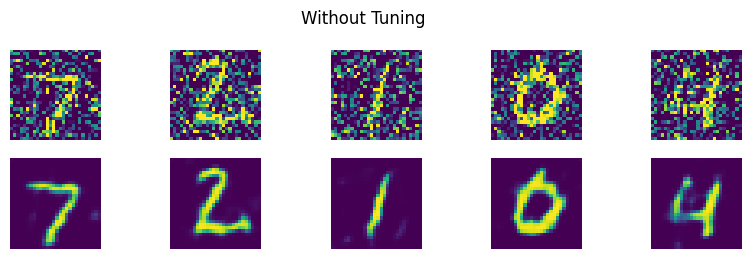

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models

# Load dataset
(x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()

# Normalize
x_train = x_train / 255.0
x_test = x_test / 255.0

# Add noise
noise_factor = 0.5
x_train_noisy = x_train + noise_factor * np.random.normal(size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(size=x_test.shape)

# Clip values
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

# Reshape
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)
x_train_noisy = x_train_noisy.reshape(-1, 28, 28, 1)
x_test_noisy = x_test_noisy.reshape(-1, 28, 28, 1)

# Build Autoencoder
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2), padding='same'),
    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.UpSampling2D((2,2)),
    layers.Conv2D(1, (3,3), activation='sigmoid', padding='same')
])

model.compile(optimizer='adam', loss='mse')

# Train
history1 = model.fit(x_train_noisy, x_train, epochs=5, batch_size=128,
                     validation_data=(x_test_noisy, x_test))

# Predict
decoded_imgs1 = model.predict(x_test_noisy)

# Show images
plt.figure(figsize=(10,4))
for i in range(5):
    # Noisy
    plt.subplot(3,5,i+1)
    plt.imshow(x_test_noisy[i].reshape(28,28))
    plt.axis('off')

    # Denoised
    plt.subplot(3,5,i+6)
    plt.imshow(decoded_imgs1[i].reshape(28,28))
    plt.axis('off')

plt.suptitle("Without Tuning")
plt.show()


Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 148s 156ms/step - loss: 0.1129 - val_loss: 0.1140
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 138s 148ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 142s 147ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 144s 153ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 137s 146ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 143s 153ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 137s 146ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 145s 149ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 9/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 139s 148ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 10/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 141s 147ms/step - loss: 0.1120 - val_loss: 0.1140
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step


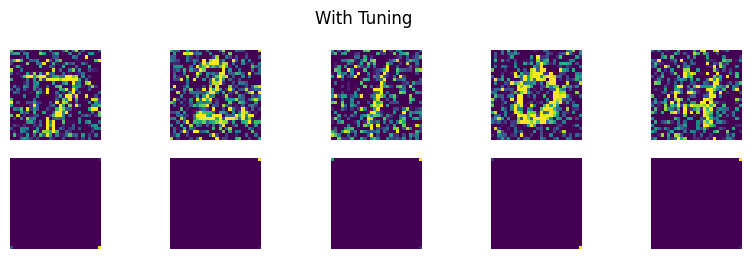

In [2]:
# Tuned Autoencoder

model2 = models.Sequential([
    layers.Conv2D(64, (3,3), activation='relu', padding='same', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2), padding='same'),
    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.UpSampling2D((2,2)),
    layers.Conv2D(1, (3,3), activation='sigmoid', padding='same')
])

model2.compile(optimizer='adam', loss='mse')

# Train with tuned parameters
history2 = model2.fit(x_train_noisy, x_train, epochs=10, batch_size=64,
                      validation_data=(x_test_noisy, x_test))

# Predict
decoded_imgs2 = model2.predict(x_test_noisy)

# Show images
plt.figure(figsize=(10,4))
for i in range(5):
    # Noisy
    plt.subplot(3,5,i+1)
    plt.imshow(x_test_noisy[i].reshape(28,28))
    plt.axis('off')

    # Denoised
    plt.subplot(3,5,i+6)
    plt.imshow(decoded_imgs2[i].reshape(28,28))
    plt.axis('off')

plt.suptitle("With Tuning")
plt.show()
